[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/0_BinaryClassification_Titanic_structured_data.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 12 (M2.3) - Titanic: prep and the baseline to beat

- New question, same skeleton: who survives? Binary classification with a network.
- The wrangling IS the lesson: drop cabin (too missing), impute age with the mean, drop 2 missing embarked rows, LabelEncoder sex/embarked - dot products need numbers.
- THE BASELINE: 61.7% die - so a model predicting 'everyone dies' scores 61.7% with zero skill. Any real model must beat the majority class. Say this hard; it's the M1 accuracy lesson wearing a costume.
-->

# Classification with DNNs: Titanic
-------------------------------
**Dr. Dave Wanik**

Can you predict whether someone will survive the Titanic or not?

A description of the data can be found here: https://www.kaggle.com/c/titanic/data

In [1]:
# modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

!pip install scikeras
from scikeras.wrappers import KerasClassifier # updated 2023
#from keras.wrappers.scikit_learn import KerasClassifier
#from keras.utils import np_utils

# for modeling
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\dww05002\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## EDA
Read in the data, check for missing values, some interesting plots.

In [2]:
# # read data from github
# df = pd.read_csv('https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/train.csv')

In [3]:
# # read from shareable link
# # https://drive.google.com/file/d/1-sfX5y1olZm7_0iZcY1-mP2LyvTTcaNH/view?usp=sharing
# !gdown 1-sfX5y1olZm7_0iZcY1-mP2LyvTTcaNH
# df = pd.read_csv('../data/titanic_train.csv')

In [4]:
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/titanic_train.csv"

# retrieve the data and build a dataframe
df = pd.read_csv(url)

df.shape

(891, 12)

In [5]:
# check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
# for simplicity, we will impute AGE with the mean, and delete the cabin column,
# then delete any rows with missing values (should only be from 'Embarked')

# first, delete the cabin column
df.drop(['Cabin'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.1 KB


In [7]:
# now impute the 'Age' column - assign the result back!
# (inplace fillna on a single column no longer writes through in modern pandas)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.1 KB


In [8]:
# now ditch the two rows from 'Embarked'
df.dropna(inplace=True)

In [9]:
# voila! 889 rows.
df.info()

# now let's clean up the test data

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 118.0 KB


In [10]:
# check out the test data for missing values
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 118.0 KB


In [11]:
# check out the data
df.head()

# we see PassengerID, Name and Ticket probably aren't useful,
# and that the Sex and Embarked column needs to get recoded into a number

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [12]:
# drop unncessary columns from train and testdf
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# recode the sex column - assign the result back!
# (inplace replace on a single column no longer writes through in modern pandas)
df['Sex'] = df['Sex'].replace(('male', 'female'), (0, 1))

# recode the embarked column
df['Embarked'] = df['Embarked'].replace(('Q', 'S', 'C'), (0, 1, 2))

# check your work - great! ready for modeling.
print(df.info())
df.head()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB
None


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,1
3,1,1,1,35.0,1,0,53.1000,1
4,0,3,0,35.0,0,0,8.0500,1


In [13]:
# check your work - great! ready for modeling.
print(df.info())
df.head()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB
None


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,1
3,1,1,1,35.0,1,0,53.1000,1
4,0,3,0,35.0,0,0,8.0500,1


In [14]:
# check distribution of target variable
df['Survived'].value_counts()

Survived
0    549
1    340
Name: count, dtype: int64

In [15]:
# if your model is smart, it should have an accuracy better
# than a dummy model (that just predicts the majority class)
(549/(549+340))

0.6175478065241845

## Split Data into X and Y

In [16]:
# split into X and Y
Y = df['Survived']
X = df.drop(['Survived'], axis=1)

print(X.shape)
print(Y.shape)

(889, 7)
(889,)


In [17]:
# convert to numpy arrays - and force a real numeric dtype.
# Keras 3 refuses object-dtype arrays that older versions quietly coerced.
X = np.array(X).astype('float32')
Y = np.array(Y).astype('float32')

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 13 (M2.3) - Titanic: sigmoid, binary_crossentropy, confusion matrix

- Two changes from regression and ONLY two: output = Dense(1, sigmoid), loss = binary_crossentropy. Everything else identical.
- The sigmoid squishes to a 0-1 PROBABILITY - the exact predict_proba idea from M1, now coming out of a network. Threshold at 0.5 to get a class.
- binary_crossentropy rewards confident correct predictions and punishes confident wrong ones.
- Fit with early stopping -> ~83%, beats the 61.7% baseline. Round the sigmoid outputs for the confusion matrix; read precision vs recall in Titanic terms.
- CAREFUL on AUC if you mention it: high AUC = good class SEPARATION. (Do not repeat the M1 video 9 slip.)
-->

## Build a Model - no callbacks
Let's build a dense neural network!

In [18]:
# build a model
model = Sequential()
model.add(Dense(16, input_shape=(X.shape[1],), activation='relu')) # don't forget to add an input shape! (features,)
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# compile the model
model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [20]:
# fit the model
history = model.fit(X,
                    Y,
                    epochs=80,
                    batch_size=10,
                    validation_split=0.2,
                    shuffle=True)

Epoch 1/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1:12 1s/step - accuracy: 0.3000 - loss: 7.3044

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4818 - loss: 3.1787 

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5571 - loss: 2.0821

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5598 - loss: 2.0617 - val_accuracy: 0.6966 - val_loss: 0.7205


Epoch 2/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6000 - loss: 1.9396

39/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6436 - loss: 0.8596 

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6471 - loss: 0.8239

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6512 - loss: 0.8202 - val_accuracy: 0.7022 - val_loss: 0.5864


Epoch 3/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.4000 - loss: 0.8746

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6432 - loss: 0.6444 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6667 - loss: 0.6496

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6667 - loss: 0.6496 - val_accuracy: 0.7416 - val_loss: 0.5407


Epoch 4/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6000 - loss: 0.5770

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6571 - loss: 0.6383 

66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6773 - loss: 0.6252

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6737 - loss: 0.6274 - val_accuracy: 0.7472 - val_loss: 0.5225


Epoch 5/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9000 - loss: 0.4240

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7162 - loss: 0.5693 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6878 - loss: 0.6022

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6878 - loss: 0.6022 - val_accuracy: 0.7191 - val_loss: 0.6328


Epoch 6/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6000 - loss: 0.6962

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6939 - loss: 0.6589 

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6970 - loss: 0.6193

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6990 - loss: 0.6146 - val_accuracy: 0.7753 - val_loss: 0.5044


Epoch 7/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6000 - loss: 0.5931

34/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7265 - loss: 0.5680 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7075 - loss: 0.5802 - val_accuracy: 0.7247 - val_loss: 0.5474


Epoch 8/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7000 - loss: 0.5742

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6789 - loss: 0.6960 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6892 - loss: 0.6299 - val_accuracy: 0.7697 - val_loss: 0.4911


Epoch 9/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.6834

31/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7129 - loss: 0.5720 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7123 - loss: 0.5769

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7117 - loss: 0.5772 - val_accuracy: 0.7921 - val_loss: 0.4823


Epoch 10/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.4644

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7237 - loss: 0.5697 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7286 - loss: 0.5556 - val_accuracy: 0.7640 - val_loss: 0.4807


Epoch 11/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.6000 - loss: 0.5833

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7139 - loss: 0.5528 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7225 - loss: 0.5540

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7229 - loss: 0.5536 - val_accuracy: 0.7472 - val_loss: 0.5486


Epoch 12/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.6000 - loss: 0.8427

29/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7310 - loss: 0.5641 

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7388 - loss: 0.5469

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7314 - loss: 0.5542 - val_accuracy: 0.7753 - val_loss: 0.4676


Epoch 13/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 1.0000 - loss: 0.3504

26/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7885 - loss: 0.5107 

61/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7377 - loss: 0.5534

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7440 - loss: 0.5441 - val_accuracy: 0.7865 - val_loss: 0.4467


Epoch 14/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 1.0000 - loss: 0.2883

40/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7700 - loss: 0.5312 

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7388 - loss: 0.5406

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7398 - loss: 0.5395 - val_accuracy: 0.7921 - val_loss: 0.4706


Epoch 15/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 1.0000 - loss: 0.3648

27/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7593 - loss: 0.5459 

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7514 - loss: 0.5461

55/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7545 - loss: 0.5351

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7482 - loss: 0.5419

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7482 - loss: 0.5419 - val_accuracy: 0.7640 - val_loss: 0.5337


Epoch 16/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7000 - loss: 0.5616

23/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6826 - loss: 0.6193 

43/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7233 - loss: 0.5547

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7138 - loss: 0.5636

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7145 - loss: 0.5583 - val_accuracy: 0.7247 - val_loss: 0.5261


Epoch 17/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8000 - loss: 0.4595

25/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7520 - loss: 0.5291 

52/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7865 - loss: 0.5031

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7651 - loss: 0.5121 - val_accuracy: 0.7865 - val_loss: 0.4569


Epoch 18/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9000 - loss: 0.3870

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4883 

61/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7885 - loss: 0.4977

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7820 - loss: 0.5052 - val_accuracy: 0.8090 - val_loss: 0.4215


Epoch 19/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7000 - loss: 0.4911

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7364 - loss: 0.5319 

58/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5289

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7595 - loss: 0.5179 - val_accuracy: 0.7921 - val_loss: 0.4159


Epoch 20/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9000 - loss: 0.3877

26/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7577 - loss: 0.5173 

54/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7556 - loss: 0.5150

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7693 - loss: 0.5008 - val_accuracy: 0.8146 - val_loss: 0.4178


Epoch 21/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8000 - loss: 0.3954

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7767 - loss: 0.4794 

59/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7627 - loss: 0.5264

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7665 - loss: 0.5225 - val_accuracy: 0.8090 - val_loss: 0.4458


Epoch 22/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7000 - loss: 0.5761

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7812 - loss: 0.4697 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7554 - loss: 0.5274

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7553 - loss: 0.5414 - val_accuracy: 0.8146 - val_loss: 0.4386


Epoch 23/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.5000 - loss: 0.8560

21/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7476 - loss: 0.5312  

45/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7667 - loss: 0.4960

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7764 - loss: 0.4947 - val_accuracy: 0.8371 - val_loss: 0.4371


Epoch 24/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6000 - loss: 0.8453

23/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7913 - loss: 0.5002 

52/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.4886

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4856 - val_accuracy: 0.8090 - val_loss: 0.4200


Epoch 25/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7000 - loss: 0.4699

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7767 - loss: 0.4900 

55/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.4661

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7862 - loss: 0.4857 - val_accuracy: 0.8427 - val_loss: 0.3966


Epoch 26/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9000 - loss: 0.4308

24/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.5012 

47/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7745 - loss: 0.4988

68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7897 - loss: 0.4868

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7904 - loss: 0.4867 - val_accuracy: 0.8202 - val_loss: 0.3944


Epoch 27/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9000 - loss: 0.3551

24/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7792 - loss: 0.4891 

49/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7776 - loss: 0.5021

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7890 - loss: 0.4893 - val_accuracy: 0.7978 - val_loss: 0.4147


Epoch 28/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9000 - loss: 0.3032

31/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7677 - loss: 0.5136 

63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7984 - loss: 0.4767

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4742 - val_accuracy: 0.7978 - val_loss: 0.4177


Epoch 29/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8000 - loss: 0.3793

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7750 - loss: 0.4630 

61/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7787 - loss: 0.4850

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7834 - loss: 0.4837 - val_accuracy: 0.7978 - val_loss: 0.4725


Epoch 30/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.8000 - loss: 0.5175

23/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7870 - loss: 0.4667 

51/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7804 - loss: 0.4838

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7904 - loss: 0.4715 - val_accuracy: 0.8090 - val_loss: 0.4120


Epoch 31/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9000 - loss: 0.3762

28/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7786 - loss: 0.4716 

57/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7754 - loss: 0.4763

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7876 - loss: 0.4663 - val_accuracy: 0.8371 - val_loss: 0.3780


Epoch 32/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 1.0000 - loss: 0.2821

28/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8036 - loss: 0.4624 

52/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7942 - loss: 0.4735

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7918 - loss: 0.4718 - val_accuracy: 0.8090 - val_loss: 0.4837


Epoch 33/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9000 - loss: 0.3697

23/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7696 - loss: 0.4858 

47/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7723 - loss: 0.4853

69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7609 - loss: 0.4819

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7651 - loss: 0.4819 - val_accuracy: 0.8202 - val_loss: 0.3867


Epoch 34/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7000 - loss: 0.5121

29/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4795 

59/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7847 - loss: 0.4858

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4840 - val_accuracy: 0.8202 - val_loss: 0.3999


Epoch 35/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6000 - loss: 0.7113

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7727 - loss: 0.4915 

66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7894 - loss: 0.4650

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4627 - val_accuracy: 0.8202 - val_loss: 0.3921


Epoch 36/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5000 - loss: 0.7933

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7684 - loss: 0.4788 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4724 - val_accuracy: 0.8146 - val_loss: 0.3908


Epoch 37/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 0.2198

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7629 - loss: 0.4705 

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7700 - loss: 0.4809

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4778 - val_accuracy: 0.7921 - val_loss: 0.4337


Epoch 38/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9000 - loss: 0.3368

43/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7791 - loss: 0.4744 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.4814 - val_accuracy: 0.8202 - val_loss: 0.3962


Epoch 39/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9000 - loss: 0.3442

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7939 - loss: 0.4765 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4617

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8003 - loss: 0.4613 - val_accuracy: 0.8034 - val_loss: 0.4099


Epoch 40/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7000 - loss: 0.5335

39/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7949 - loss: 0.4550 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4647 - val_accuracy: 0.7921 - val_loss: 0.4520


Epoch 41/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7000 - loss: 0.7023

40/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8075 - loss: 0.4566 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8003 - loss: 0.4595 - val_accuracy: 0.8034 - val_loss: 0.4427


Epoch 42/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9000 - loss: 0.2743

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7833 - loss: 0.4256 

64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7828 - loss: 0.4531

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4552 - val_accuracy: 0.8202 - val_loss: 0.3822


Epoch 43/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8000 - loss: 0.6152

26/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7846 - loss: 0.4737 

63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8016 - loss: 0.4571

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4627 - val_accuracy: 0.8202 - val_loss: 0.3747


Epoch 44/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9000 - loss: 0.3272

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7778 - loss: 0.4827 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4644 - val_accuracy: 0.8258 - val_loss: 0.3853


Epoch 45/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8000 - loss: 0.5575

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7937 - loss: 0.4658 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7892 - loss: 0.4587

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4670 - val_accuracy: 0.8202 - val_loss: 0.3971


Epoch 46/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8000 - loss: 0.4805

42/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7643 - loss: 0.4808 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7820 - loss: 0.5103 - val_accuracy: 0.8090 - val_loss: 0.4297


Epoch 47/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9000 - loss: 0.2393

29/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7310 - loss: 0.8575 

64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.6569

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7581 - loss: 0.6385 - val_accuracy: 0.8315 - val_loss: 0.3752


Epoch 48/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9000 - loss: 0.4256

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7657 - loss: 0.5063 

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7729 - loss: 0.4876

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7722 - loss: 0.4881 - val_accuracy: 0.8202 - val_loss: 0.3779


Epoch 49/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.5458

39/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7641 - loss: 0.4852 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4532 - val_accuracy: 0.8202 - val_loss: 0.3719


Epoch 50/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9000 - loss: 0.3624

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7972 - loss: 0.4206 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7915 - loss: 0.4571

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4590 - val_accuracy: 0.7921 - val_loss: 0.4282


Epoch 51/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 1.0000 - loss: 0.2966

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7879 - loss: 0.4811 

64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7875 - loss: 0.4690

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7918 - loss: 0.4616 - val_accuracy: 0.8258 - val_loss: 0.3686


Epoch 52/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7000 - loss: 0.4534

39/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7923 - loss: 0.4538 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7918 - loss: 0.4586 - val_accuracy: 0.8146 - val_loss: 0.3729


Epoch 53/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9000 - loss: 0.6375

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7946 - loss: 0.4653 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4522 - val_accuracy: 0.8146 - val_loss: 0.3695


Epoch 54/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9000 - loss: 0.3878

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8028 - loss: 0.4695 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4662 - val_accuracy: 0.8258 - val_loss: 0.3815


Epoch 55/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9000 - loss: 0.4542

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7778 - loss: 0.4607 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4551 - val_accuracy: 0.8315 - val_loss: 0.3722


Epoch 56/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.1177

31/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4572 

66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8015 - loss: 0.4590

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8059 - loss: 0.4515 - val_accuracy: 0.7978 - val_loss: 0.4646


Epoch 57/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5000 - loss: 0.6646

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7595 - loss: 0.5213 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7806 - loss: 0.5035

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7806 - loss: 0.5035 - val_accuracy: 0.8258 - val_loss: 0.3738


Epoch 58/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.4528

34/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7941 - loss: 0.4672 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.4652

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4703 - val_accuracy: 0.8202 - val_loss: 0.3845


Epoch 59/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7000 - loss: 0.6533

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7567 - loss: 0.4691 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7918 - loss: 0.4515 - val_accuracy: 0.8146 - val_loss: 0.3914


Epoch 60/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8000 - loss: 0.3884

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7800 - loss: 0.4620 

66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7909 - loss: 0.4539

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4480 - val_accuracy: 0.8258 - val_loss: 0.3844


Epoch 61/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7000 - loss: 0.4615

27/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7926 - loss: 0.4520 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4508 - val_accuracy: 0.8315 - val_loss: 0.3622


Epoch 62/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9000 - loss: 0.2791

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8031 - loss: 0.4410 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7986 - loss: 0.4641

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4656 - val_accuracy: 0.8258 - val_loss: 0.3828


Epoch 63/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6000 - loss: 0.5533

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8139 - loss: 0.4565 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4670 - val_accuracy: 0.8146 - val_loss: 0.3649


Epoch 64/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7000 - loss: 0.6186

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8067 - loss: 0.4346 

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7836 - loss: 0.4548

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4547 - val_accuracy: 0.8090 - val_loss: 0.3828


Epoch 65/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6000 - loss: 0.6080

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7972 - loss: 0.4285 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4529 - val_accuracy: 0.8315 - val_loss: 0.3624


Epoch 66/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7000 - loss: 0.4498

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7972 - loss: 0.4556 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7918 - loss: 0.4508 - val_accuracy: 0.8202 - val_loss: 0.3968


Epoch 67/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9000 - loss: 0.3308

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.5919 

69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7812 - loss: 0.5474

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.5466 - val_accuracy: 0.8202 - val_loss: 0.4039


Epoch 68/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7000 - loss: 0.5211

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7750 - loss: 0.5016 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4689 - val_accuracy: 0.8146 - val_loss: 0.3687


Epoch 69/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 0.2737

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8212 - loss: 0.4431 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8003 - loss: 0.4497 - val_accuracy: 0.8258 - val_loss: 0.3729


Epoch 70/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9000 - loss: 0.2805

27/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7852 - loss: 0.4922 

60/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7983 - loss: 0.4539

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.4582 - val_accuracy: 0.8315 - val_loss: 0.3626


Epoch 71/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9000 - loss: 0.4231

29/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7828 - loss: 0.4758 

66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7803 - loss: 0.4706

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4660 - val_accuracy: 0.8315 - val_loss: 0.3746


Epoch 72/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8000 - loss: 0.4372

46/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7978 - loss: 0.4538 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4481 - val_accuracy: 0.8258 - val_loss: 0.3725


Epoch 73/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9000 - loss: 0.3912

39/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7897 - loss: 0.4859 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7975 - loss: 0.4585

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4585 - val_accuracy: 0.8258 - val_loss: 0.3641


Epoch 74/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9000 - loss: 0.4154

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7919 - loss: 0.4818 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4616 - val_accuracy: 0.8371 - val_loss: 0.3856


Epoch 75/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8000 - loss: 0.5341

40/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4079 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7750 - loss: 0.4708 - val_accuracy: 0.8202 - val_loss: 0.3783


Epoch 76/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9000 - loss: 0.3290

26/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7346 - loss: 0.8282 

69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7681 - loss: 0.6079

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7707 - loss: 0.6011 - val_accuracy: 0.8258 - val_loss: 0.3708


Epoch 77/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8000 - loss: 0.4015

34/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.4540 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8014 - loss: 0.4465

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8017 - loss: 0.4463 - val_accuracy: 0.8090 - val_loss: 0.4095


Epoch 78/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9000 - loss: 0.2137

42/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7929 - loss: 0.4621 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4620 - val_accuracy: 0.8202 - val_loss: 0.3729


Epoch 79/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5000 - loss: 0.8287

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8056 - loss: 0.4412 

69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7942 - loss: 0.4506

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.4556 - val_accuracy: 0.8202 - val_loss: 0.3619


Epoch 80/80


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7000 - loss: 0.6493

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4431 

62/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8032 - loss: 0.4404

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8003 - loss: 0.4471 - val_accuracy: 0.8202 - val_loss: 0.3942


In [21]:
# now you could plot the epochs and train for exactly that many...
# but callbacks and early stopping are way better!
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

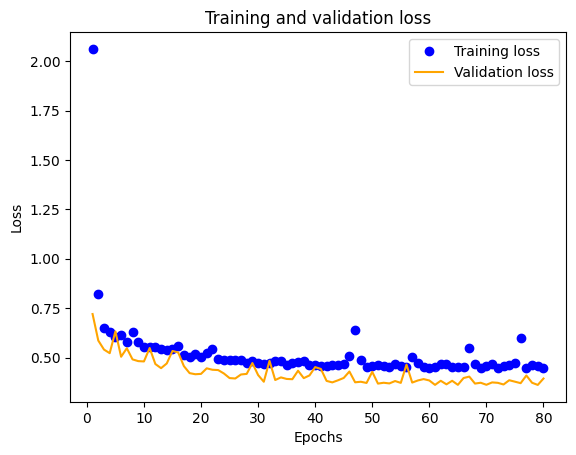

In [22]:
# can paste in learning curve code from previous examples
# just need to update dictionary keys to accuracy etc.

# let's see the training and validation loss by epoch
history_dict = history.history
loss_values = history_dict['loss'] # you can change this
val_loss_values = history_dict['val_loss'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'orange', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

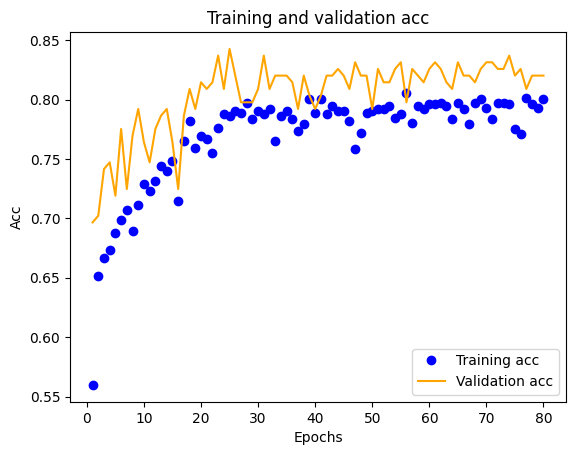

In [23]:
# let's see the training and validation accuracy by epoch
history_dict = history.history
loss_values = history_dict['accuracy'] # you can change this
val_loss_values = history_dict['val_accuracy'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training acc')
plt.plot(epochs, val_loss_values, 'orange', label='Validation acc')
plt.title('Training and validation acc')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()
plt.show()

## Build a Model - with callbacks
Let's introduce early stopping, we could also introduce some weight regularization then revisualization our network.

Link: https://keras.io/api/callbacks/early_stopping/

In [24]:
# fresh start! clear the old model and rebuild from scratch
# gotcha: re-running fit on an existing model CONTINUES training from
# wherever it left off... great for resuming, terrible for a fair comparison!
import keras
keras.backend.clear_session()

model = Sequential()
model.add(Dense(16, input_shape=(X.shape[1],), activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [25]:
# we will keep the same model architecture as before,
# but we will make this a little simpler...

# early stopping callback
# This callback will stop the training when there is no improvement in
# the validation loss for 10 consecutive epochs.
es = EarlyStopping(monitor='val_accuracy',
                                   mode='max', # don't minimize the accuracy!
                                   patience=20,
                                   restore_best_weights=True)

# now we just update our model fit call
history = model.fit(X,
                    Y,
                    callbacks=[es],
                    epochs=1000, # you can set this to a big number!
                    batch_size=10,
                    validation_split=0.2,
                    shuffle=True,
                    verbose=1)

Epoch 1/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1:06 941ms/step - accuracy: 0.5000 - loss: 8.2173

42/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5810 - loss: 5.6292    

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5809 - loss: 4.3681 - val_accuracy: 0.3652 - val_loss: 1.6797


Epoch 2/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.3000 - loss: 2.1840

31/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3677 - loss: 1.0483 

66/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4348 - loss: 0.8872

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4501 - loss: 0.8713 - val_accuracy: 0.7022 - val_loss: 0.6425


Epoch 3/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7000 - loss: 0.6216

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6763 - loss: 0.6502 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6709 - loss: 0.6508 - val_accuracy: 0.7697 - val_loss: 0.5787


Epoch 4/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7000 - loss: 0.6216

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6789 - loss: 0.6133 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6906 - loss: 0.6226 - val_accuracy: 0.7079 - val_loss: 0.5999


Epoch 5/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6000 - loss: 0.7696

42/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7095 - loss: 0.6102 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7004 - loss: 0.6058 - val_accuracy: 0.7303 - val_loss: 0.5195


Epoch 6/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7000 - loss: 0.4810

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6816 - loss: 0.5949 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7075 - loss: 0.5847 - val_accuracy: 0.7809 - val_loss: 0.5108


Epoch 7/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7000 - loss: 0.5513

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7188 - loss: 0.5703 

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7143 - loss: 0.5671

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7131 - loss: 0.5695 - val_accuracy: 0.7809 - val_loss: 0.4867


Epoch 8/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9000 - loss: 0.2934

28/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7321 - loss: 0.5248 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7308 - loss: 0.5524

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7300 - loss: 0.5580 - val_accuracy: 0.7809 - val_loss: 0.5139


Epoch 9/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7000 - loss: 0.6787

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7432 - loss: 0.5535 

68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7294 - loss: 0.5592

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7300 - loss: 0.5578 - val_accuracy: 0.7472 - val_loss: 0.5187


Epoch 10/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7000 - loss: 0.5827

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7400 - loss: 0.5328 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7271 - loss: 0.5507 - val_accuracy: 0.8146 - val_loss: 0.4837


Epoch 11/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9000 - loss: 0.4400

39/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7513 - loss: 0.5498 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7440 - loss: 0.5412 - val_accuracy: 0.8034 - val_loss: 0.4645


Epoch 12/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.4582

34/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7294 - loss: 0.5438 

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7433 - loss: 0.5362

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7440 - loss: 0.5340 - val_accuracy: 0.7584 - val_loss: 0.4697


Epoch 13/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8000 - loss: 0.3517

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7553 - loss: 0.5376 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7511 - loss: 0.5321 - val_accuracy: 0.7753 - val_loss: 0.4650


Epoch 14/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5000 - loss: 0.6145

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7684 - loss: 0.4950 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7440 - loss: 0.5345 - val_accuracy: 0.7978 - val_loss: 0.4711


Epoch 15/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9000 - loss: 0.4986

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7378 - loss: 0.5278 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7511 - loss: 0.5159

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7511 - loss: 0.5159 - val_accuracy: 0.7921 - val_loss: 0.4776


Epoch 16/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 1.0000 - loss: 0.3138

34/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7706 - loss: 0.4995 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7665 - loss: 0.4989 - val_accuracy: 0.7865 - val_loss: 0.4980


Epoch 17/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9000 - loss: 0.4500

40/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7600 - loss: 0.5276 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7679 - loss: 0.5224 - val_accuracy: 0.8090 - val_loss: 0.4332


Epoch 18/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9000 - loss: 0.4179

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7543 - loss: 0.5019 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.5037 - val_accuracy: 0.8146 - val_loss: 0.4392


Epoch 19/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9000 - loss: 0.5904

29/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7931 - loss: 0.4601 

64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7688 - loss: 0.4931

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7722 - loss: 0.4906 - val_accuracy: 0.7921 - val_loss: 0.4622


Epoch 20/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8000 - loss: 0.5572

43/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7721 - loss: 0.4898 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7764 - loss: 0.4908 - val_accuracy: 0.8090 - val_loss: 0.4356


Epoch 21/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9000 - loss: 0.4115

51/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8020 - loss: 0.4744 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4872 - val_accuracy: 0.8034 - val_loss: 0.4313


Epoch 22/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.5000 - loss: 0.7088

43/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7884 - loss: 0.4806  

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7778 - loss: 0.4887 - val_accuracy: 0.8202 - val_loss: 0.4095


Epoch 23/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.3000 - loss: 0.8300

40/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8025 - loss: 0.4464 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7750 - loss: 0.4840 - val_accuracy: 0.7978 - val_loss: 0.4323


Epoch 24/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 1.0000 - loss: 0.2772

46/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7870 - loss: 0.4898 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7651 - loss: 0.5078 - val_accuracy: 0.8146 - val_loss: 0.4079


Epoch 25/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8000 - loss: 0.4189

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7865 - loss: 0.4569 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4738 - val_accuracy: 0.8146 - val_loss: 0.4174


Epoch 26/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7000 - loss: 0.4787

45/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7711 - loss: 0.4771 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4691 - val_accuracy: 0.8090 - val_loss: 0.4042


Epoch 27/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5000 - loss: 0.5423

28/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7679 - loss: 0.4748 

64/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7875 - loss: 0.4657

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4678 - val_accuracy: 0.8090 - val_loss: 0.4055


Epoch 28/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8000 - loss: 0.5576

26/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7923 - loss: 0.4784 

67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7910 - loss: 0.4683

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7918 - loss: 0.4670 - val_accuracy: 0.8258 - val_loss: 0.4055


Epoch 29/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9000 - loss: 0.2905

35/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7971 - loss: 0.4845 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7989 - loss: 0.4642 - val_accuracy: 0.8202 - val_loss: 0.4042


Epoch 30/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7000 - loss: 0.5628

41/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7634 - loss: 0.5294 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.4961 - val_accuracy: 0.8090 - val_loss: 0.4032


Epoch 31/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9000 - loss: 0.2943

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7789 - loss: 0.4552 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7862 - loss: 0.4581

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4581 - val_accuracy: 0.8146 - val_loss: 0.4016


Epoch 32/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8000 - loss: 0.3644

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7833 - loss: 0.4531 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4626 - val_accuracy: 0.8090 - val_loss: 0.3991


Epoch 33/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8000 - loss: 0.4234

27/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7593 - loss: 0.4747 

63/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7825 - loss: 0.4623

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4573 - val_accuracy: 0.8146 - val_loss: 0.3878


Epoch 34/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7000 - loss: 0.4524

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7784 - loss: 0.4639 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4613 - val_accuracy: 0.8146 - val_loss: 0.4051


Epoch 35/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8000 - loss: 0.4706

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8132 - loss: 0.4375 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4617 - val_accuracy: 0.8202 - val_loss: 0.3909


Epoch 36/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5000 - loss: 0.4986

30/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7667 - loss: 0.4972 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7736 - loss: 0.4848 - val_accuracy: 0.8371 - val_loss: 0.3880


Epoch 37/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 1.0000 - loss: 0.1471

31/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7871 - loss: 0.4761 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7862 - loss: 0.4565

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4589 - val_accuracy: 0.8371 - val_loss: 0.3798


Epoch 38/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9000 - loss: 0.2624

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7611 - loss: 0.5024 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4663 - val_accuracy: 0.8371 - val_loss: 0.3830


Epoch 39/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9000 - loss: 0.2514

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4655 

69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7899 - loss: 0.4666

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.4705 - val_accuracy: 0.8483 - val_loss: 0.3837


Epoch 40/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7000 - loss: 0.4268

27/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8148 - loss: 0.4098 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7873 - loss: 0.4615

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7862 - loss: 0.4623 - val_accuracy: 0.8202 - val_loss: 0.3928


Epoch 41/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9000 - loss: 0.3336

42/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7905 - loss: 0.4464 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4551 - val_accuracy: 0.8371 - val_loss: 0.3729


Epoch 42/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9000 - loss: 0.2549

34/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8235 - loss: 0.4292 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4540 - val_accuracy: 0.8202 - val_loss: 0.3979


Epoch 43/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7000 - loss: 0.5551

42/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7833 - loss: 0.4549 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7806 - loss: 0.4809 - val_accuracy: 0.8034 - val_loss: 0.4073


Epoch 44/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8000 - loss: 0.4758

32/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8062 - loss: 0.4615 

65/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7908 - loss: 0.4716

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4677 - val_accuracy: 0.8034 - val_loss: 0.4153


Epoch 45/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7000 - loss: 0.6710

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7917 - loss: 0.4654 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4587 - val_accuracy: 0.8090 - val_loss: 0.3865


Epoch 46/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7000 - loss: 0.6937

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7515 - loss: 0.4909 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7792 - loss: 0.4604 - val_accuracy: 0.8202 - val_loss: 0.3869


Epoch 47/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9000 - loss: 0.3558

54/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7907 - loss: 0.4452 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7820 - loss: 0.4511 - val_accuracy: 0.8202 - val_loss: 0.3944


Epoch 48/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9000 - loss: 0.5130

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7892 - loss: 0.4513 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7848 - loss: 0.4595

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4595 - val_accuracy: 0.8202 - val_loss: 0.3939


Epoch 49/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9000 - loss: 0.2155

40/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7725 - loss: 0.4844 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4549 - val_accuracy: 0.8202 - val_loss: 0.3866


Epoch 50/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9000 - loss: 0.2491

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7595 - loss: 0.4799 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.4498 - val_accuracy: 0.8146 - val_loss: 0.3993


Epoch 51/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9000 - loss: 0.3472

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8026 - loss: 0.4521 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4640 - val_accuracy: 0.8258 - val_loss: 0.3856


Epoch 52/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 1.0000 - loss: 0.2197

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8378 - loss: 0.3750 

70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7786 - loss: 0.4572

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7806 - loss: 0.4561 - val_accuracy: 0.8315 - val_loss: 0.3760


Epoch 53/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 1.0000 - loss: 0.1435

27/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8148 - loss: 0.4234 

71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7915 - loss: 0.4575

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4585 - val_accuracy: 0.8202 - val_loss: 0.4081


Epoch 54/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9000 - loss: 0.3719

33/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7697 - loss: 0.4693 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7904 - loss: 0.4524

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4524 - val_accuracy: 0.8034 - val_loss: 0.4022


Epoch 55/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7000 - loss: 0.5023

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7833 - loss: 0.4518 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7890 - loss: 0.4522 - val_accuracy: 0.8146 - val_loss: 0.3882


Epoch 56/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9000 - loss: 0.3582

38/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7789 - loss: 0.4626 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7848 - loss: 0.4498 - val_accuracy: 0.8202 - val_loss: 0.3827


Epoch 57/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8000 - loss: 0.5791

37/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8027 - loss: 0.4484 

68/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7838 - loss: 0.4524

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7820 - loss: 0.4554 - val_accuracy: 0.8371 - val_loss: 0.3837


Epoch 58/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8000 - loss: 0.5078

36/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8167 - loss: 0.4301 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7989 - loss: 0.4540 - val_accuracy: 0.8258 - val_loss: 0.3864


Epoch 59/1000


 1/72 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 1.0000 - loss: 0.1688

47/72 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7809 - loss: 0.4678 

72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7834 - loss: 0.4588 - val_accuracy: 0.8371 - val_loss: 0.4042


## Evaluate the Model
Always check out the learning curve, show the TP, FP, TN, FN as well as the classification report.

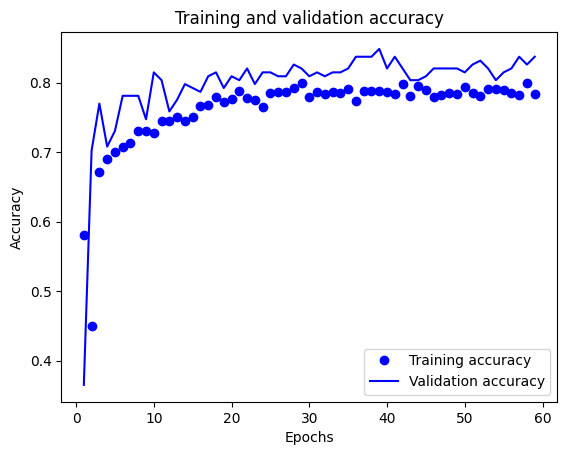

In [26]:
# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, acc, 'bo', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [27]:
# this is the max value - should correspond to
# the HIGHEST train accuracy (go look at the verbose from the model fit)
np.max(val_acc)

np.float64(0.8483145833015442)

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [29]:
# see how these are numbers between 0 and 1? prob of successes (survival)
model.predict(X)

 1/28 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.09717972],
       [0.8581589 ],
       [0.59720075],
       [0.7797835 ],
       [0.06618764],
       [0.10792229],
       [0.22478989],
       [0.12222768],
       [0.4848678 ],
       [0.814482  ],
       [0.641749  ],
       [0.6370116 ],
       [0.11273502],
       [0.02280177],
       [0.639427  ],
       [0.4818784 ],
       [0.06155441],
       [0.13107525],
       [0.56630623],
       [0.47775164],
       [0.21697429],
       [0.11316219],
       [0.6635462 ],
       [0.3817341 ],
       [0.3927262 ],
       [0.20076928],
       [0.05819685],
       [0.43215153],
       [0.6368726 ],
       [0.0797247 ],
       [0.32061866],
       [0.88460135],
       [0.63579077],
       [0.03246828],
       [0.50000226],
       [0.20292445],
       [0.05820519],
       [0.10890113],
       [0.5318192 ],
       [0.6311219 ],
       [0.40326157],
       [0.6894677 ],
       [0.05954163],
       [0.85242146],
       [0.6868273 ],
       [0.08013501],
       [0.10392425],
       [0.635

In [30]:
np.round(model.predict(X),0)

 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],

In [31]:
# here is Y
Y

array([0., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
       0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 0., 1., 1.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1.,
       0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
       0., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0.,
       0., 0., 1., 0., 1.

In [32]:
# see how the model did!
# if you don't round to a whole number (0 or 1), the confusion matrix won't work!
preds = np.round(model.predict(X),0)

# confusion matrix
confusion_matrix(Y, preds) # order matters! (actual, predicted)

# TP is bottom right
# TN is top left
# FP is top right
# FN is bottom left

# look at documentation for conf matrix on sklearn if you have questions!

 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


array([[494,  55],
       [119, 221]])

In [33]:
print(classification_report(Y, preds))

              precision    recall  f1-score   support

         0.0       0.81      0.90      0.85       549
         1.0       0.80      0.65      0.72       340

    accuracy                           0.80       889
   macro avg       0.80      0.77      0.78       889
weighted avg       0.80      0.80      0.80       889



# ⭐ On Your Own: hold out a REAL test set!

Did you notice what we just did? We trained on **ALL the data**... and then computed the confusion matrix on **that same data**. The model got graded on questions it already saw! (`validation_split` peeled off 20% during training, but our final evaluation still used every row.)

An HONEST score comes from data the model has NEVER touched. You already know the tool from the ML refresher:

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=123)
```

Now redo this notebook the right way:
* fit on `X_train` / `y_train` (keep `validation_split` for early stopping)
* confusion matrix + classification report on `X_test` / `y_test` ONLY
* compare: is your test accuracy lower than the training accuracy we got above? By how much? And does it still beat the 62% dummy baseline?

This is the single most important habit in this whole notebook... every model AFTER this one gets a proper train/test split!

# Go Play!
* Shuffle the original dataframe
* Consider pre-processing your data (MinMaxScaling, PolynomialFeatures)
  * https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
* Add more layers and change the number of hidden units
* Try to use 'tanh' instead of 'relu' and see how your results change.
* Try to use adam instead of rmsprop if you want (this includes a momentum term!), and customize it with other learning rates.
  * https://keras.io/api/optimizers/adam/
* Consider setting restore_best_weights=False and see how the confusion matrix changes.
* Try this on another dataset.